# Mini Neural Speech Decoder

This notebook demonstrates a lightweight neural-speech decoding workflow using **synthetic EEG/MEG-like signals**. The goal is not to reproduce a full brain-computer interface experiment, but to create a compact research-style pipeline that mirrors common steps used in speech decoding studies.

We simulate three neural-response classes:
- **silence**
- **vowel-like speech**
- **consonant-like speech**


## Research Motivation

Neural speech decoding research tries to map brain activity to speech-related states, such as heard phonemes, imagined speech, or articulatory intent. Real studies often use EEG, MEG, ECoG, or intracranial recordings. Here, we build a toy version of that workflow with synthetic data so the full process remains easy to run and inspect.

The notebook covers:
1. Signal simulation for 32 channels and 300 epochs
2. MNE-Python `RawArray` and `EpochsArray` creation
3. Band-pass filtering from 1 to 40 Hz
4. Simple handcrafted feature extraction
5. Multi-class logistic regression decoding
6. Performance reporting and figure export


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, display

from mini_neural_speech_decoder import CLASS_NAMES, run_pipeline

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)


## Run The Pipeline

The helper module generates structured synthetic signals, converts them into MNE containers, filters the epochs, extracts a compact feature set, and trains a logistic regression classifier.


In [2]:
pipeline = run_pipeline(results_dir)
metrics = pipeline["metrics"]

print(f"Accuracy: {metrics['accuracy']:.3f}")
print()
print("Classification report:")
print(metrics["classification_report"])
print("Confusion matrix:")
print(metrics["confusion_matrix"])


Accuracy: 1.000

Classification report:
                precision    recall  f1-score   support

       silence       1.00      1.00      1.00        25
    vowel-like       1.00      1.00      1.00        25
consonant-like       1.00      1.00      1.00        25

      accuracy                           1.00        75
     macro avg       1.00      1.00      1.00        75
  weighted avg       1.00      1.00      1.00        75

Confusion matrix:
[[25  0  0]
 [ 0 25  0]
 [ 0  0 25]]


## Feature Design

Each epoch is summarized using simple per-channel statistics:
- mean
- standard deviation
- peak amplitude
- average band power in four coarse bands: 1-4 Hz, 4-8 Hz, 8-12 Hz, and 12-30 Hz

These features are intentionally simple. They help show the structure of a decoding pipeline without introducing heavier deep learning or sequence modeling.


In [3]:
print("Feature matrix shape:", pipeline["features"].shape)
print("Epoch data shape:", pipeline["epochs"].get_data(copy=True).shape)
print("Class labels:", CLASS_NAMES)


Feature matrix shape: (300, 224)
Epoch data shape: (300, 32, 128)
Class labels: ['silence', 'vowel-like', 'consonant-like']


## Saved Figures

The following code displays the figures saved into the `results/` folder:
- example neural signal plot
- power spectral density plot
- confusion matrix


example_signal -> results/example_neural_signal.png


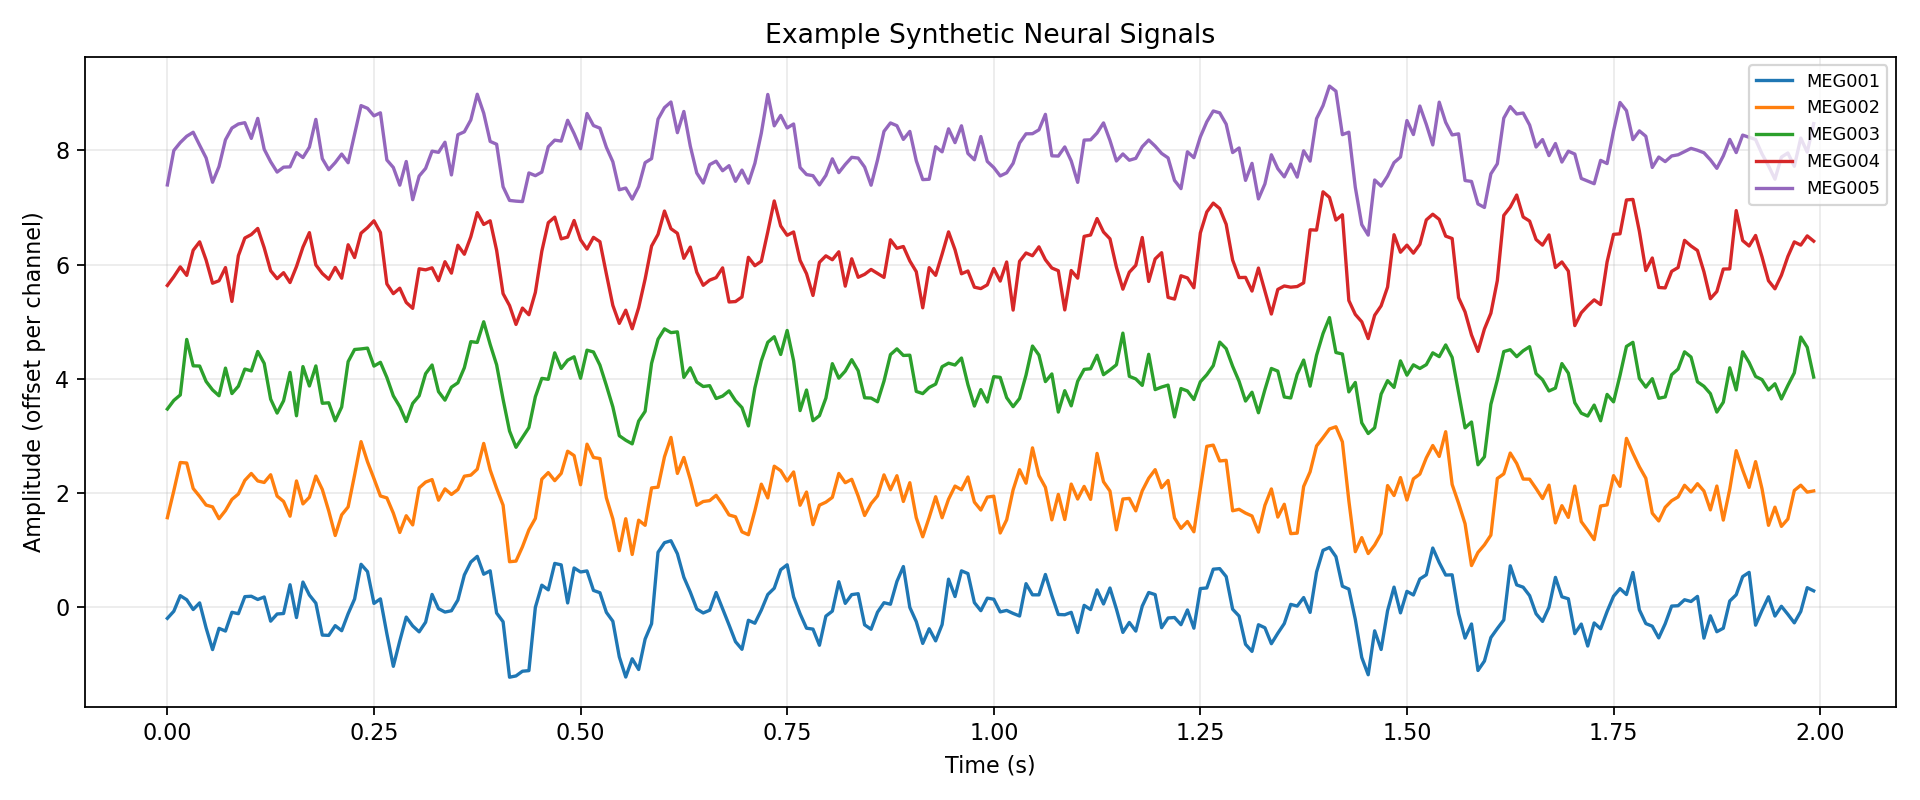

psd -> results/power_spectral_density.png


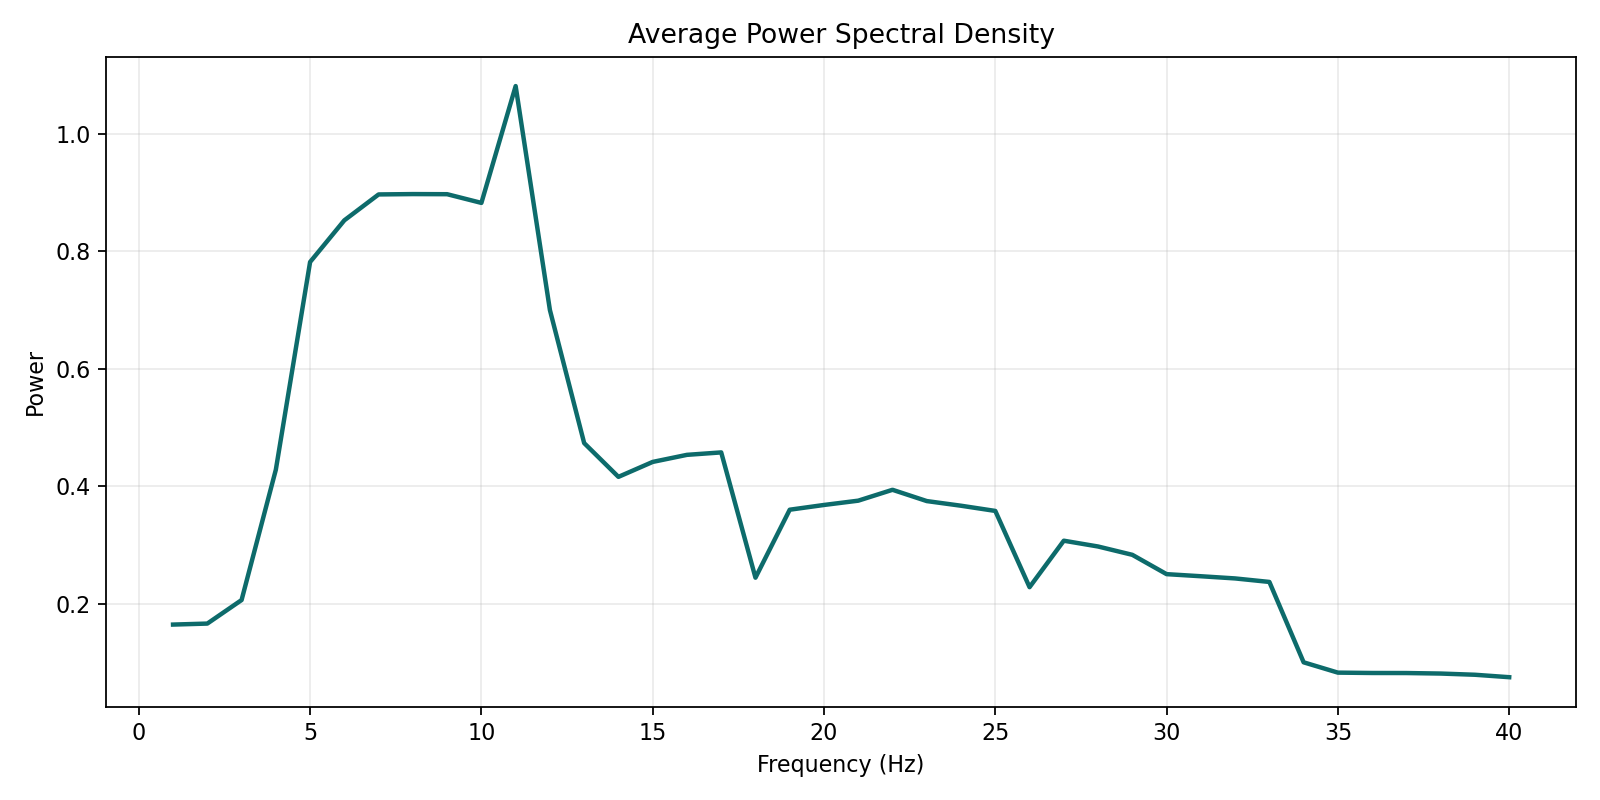

confusion_matrix -> results/confusion_matrix.png


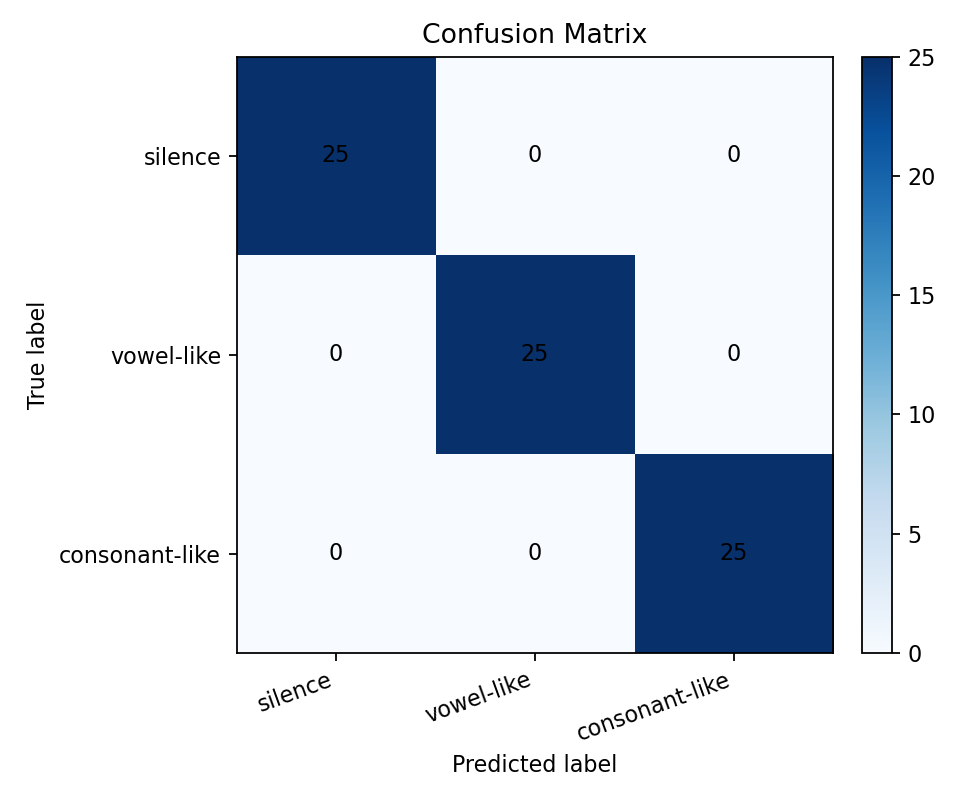

In [4]:
for label, path in pipeline["figures"].items():
    print(label, "->", path)
    display(Image(filename=str(path)))


## Interpretation

Because the classes were simulated with distinct temporal and spectral patterns, even a simple linear classifier can often separate them well. In real neural speech decoding, however, signal-to-noise ratios are lower, subject variability is high, and decoding performance depends heavily on preprocessing, alignment, and model choice.
